# Constant

In [1]:
RANDOM_STATE = 74

# Ajustement devoir 1

Liste des changements effectués sur le premier devoir :
- Enlever revenu des attributs cat et du one-hot encoding.
- Enlever la partie qui applique le pipeline sur les données pour le faire ici.
- Mise en place de la division en jeu d'entraînement et jeu de test ici.
- Préparation des pipelines pour les scénarios d'entraînement.

In [2]:
%%capture
%run devoir1.ipynb

# Sans enrichissement
pipeline_noenrich = Pipeline([
    ('preprocessor', ColumnTransformer([
        ("num", numeric_transformer, num_attribs),
        ("cat", OneHotEncoder(), cat_attribs),
    ]))
])

# Population seulement
pipeline_population = Pipeline([
    ('enrich', FunctionTransformer(enrichissement_population_pib, validate=False, kw_args={"PIB": False})),
    ('preprocessor', ColumnTransformer([
        ("num", numeric_transformer, num_attribs + ['population']),
        ("cat", OneHotEncoder(), cat_attribs),
    ]))
])

# GDP et Population
pipeline_gdppop = Pipeline([
    ('enrich', FunctionTransformer(enrichissement_population_pib, validate=False, kw_args={"PIB": True})),
    ('preprocessor', ColumnTransformer([
        ("num", numeric_transformer, num_attribs + ['population', 'GDP_inhab']),
        ("cat", OneHotEncoder(), cat_attribs),
    ]))
])

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

customer = pd.read_csv('data/Customer.csv')

# 1. Remove empty labels
customer['revenue'] = customer['revenue'].replace('unknown', np.nan)
customer = customer.dropna(subset=['revenue'])

# 2. Setup labels and remove from subjects
X = customer.drop('revenue', axis=1)
labels = customer['revenue'].copy()
labels = labels.astype(int)

# 3. Setup train and test suits
train_set, test_set, train_label, test_label = train_test_split(X, labels, test_size=0.2, random_state=RANDOM_STATE)

# Introduction
Nom : Potvin
Prénom : Ludovic  

Le but de ce travail est d'entraîner un classeur binaire et un classeur multi-classes. Ensuite, comparer les résultats des deux classeurs.

# 2.1 Classeur binaire
Mise en place d'un classeur binaire pour détecter si le sujet est susceptible ou non de produire plus de revenus que la moyenne

## 2.1.1 Fonction de remplacement revenu
Cette fonction va être utilisée pour remplacer les labels de l'entraînement pour :
- 1 : Le revenu est au-dessus de la moyenne
- 0 : Le revenu est en dessous de la moyenne

In [4]:
labels_mean = labels.mean()

def remplacement_revenue_vers_moyenne(labels):
    labels_bin = (labels > labels_mean).astype(int)

    return labels_bin

## 2.1.2 Échantillonnage aléatoire
Cette section vise à créer des échantillons aléatoires de taille 2000, 4000 et 8000.
Les échantillons seront aussi créés pour chaque scénario.

In [5]:
from sklearn.utils import resample

sample_size = [2000, 4000, 8000]

samples = {
    'noenrich': {},
    'population': {},
    'gdppop': {}
}

labels = {}

train_label_bin = remplacement_revenue_vers_moyenne(train_label)
test_label_bin = remplacement_revenue_vers_moyenne(test_label)

for size in sample_size:
    set_sample, label_sample = resample(
        train_set,
        train_label_bin,
        n_samples=size,
        random_state=RANDOM_STATE,
        stratify=train_label_bin
    )
    
    samples['noenrich'][size] = pipeline_noenrich.fit_transform(set_sample)
    samples['population'][size] = pipeline_population.fit_transform(set_sample)
    samples['gdppop'][size] = pipeline_gdppop.fit_transform(set_sample)

    labels[size] = label_sample

## 2.1.3 Entraînement par validation croisée
Ici, on va tester les modèles par validation croisée.

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate
import time

DTC = DecisionTreeClassifier(random_state=RANDOM_STATE)

results = {
    'noenrich': {},
    'population': {},
    'gdppop': {}
}

for scenario in samples:
    for size in samples[scenario]:
        X_train_set = samples[scenario][size]
        y_train_label = labels[size]

        start_time = time.time()
        score_k3 = cross_validate(DTC, X_train_set, y_train_label, cv=3, scoring=['precision', 'recall', 'f1'])
        end_time = time.time()
        k3_timing = end_time - start_time
        
        start_time = time.time()
        score_k10 = cross_validate(DTC, X_train_set, y_train_label, cv=10, scoring=['precision', 'recall', 'f1'])
        end_time = time.time()
        k10_timing = end_time - start_time
    
        results[scenario][size] = {}
        results[scenario][size]['k3'] = score_k3
        results[scenario][size]['k3']['time'] = k3_timing
        results[scenario][size]['k10'] = score_k10
        results[scenario][size]['k10']['time'] = k10_timing

In [7]:
scenario_pretty_name = {
    'noenrich': 'non enrichie',
    'population': 'avec population',
    'gdppop': 'avec population et gdp'
}

def calculate_mean(metric):
    return f"{metric.mean():.5f}"

def print_result(label, result):
    precision = calculate_mean(result['test_precision'])
    recall = calculate_mean(result['test_recall'])
    f1 = calculate_mean(result['test_f1'])
    time = f"{result['time']:.2f}s"

    print(f'{label}: {precision}   | {recall} | {f1} | {time}')

def print_training_stats():
    for scenario in results:
        # Header
        print(f'== Resultat scenario {scenario_pretty_name[scenario]} ==')
        print(f'Name   : Precision | Recall  | F1      | Time')
        # K3
        for size in results[scenario]:
            result_k3 = results[scenario][size]['k3']
            print_result(f'k3 {size}', result_k3)

        print()
        # K10
        for size in results[scenario]:
            result_k10 = results[scenario][size]['k10']
            print_result(f'k10 {size}', result_k10)


## 2.1.4 Mesurer les métriques de précision
Affichage des métriques de précision pour chaque scénario et taille d'échantillon.

In [8]:
scenario_pretty_name = {
    'noenrich': 'non enrichie',
    'population': 'avec population',
    'gdppop': 'avec population et gdp'
}

def calculate_mean(metric):
    return f"{metric.mean():.5f}"

def print_result(label, result):
    precision = calculate_mean(result['test_precision'])
    recall = calculate_mean(result['test_recall'])
    f1 = calculate_mean(result['test_f1'])
    time = f"{result['time']:.2f}s"

    print(f'{label}: {precision}   | {recall} | {f1} | {time}')

def print_training_stats():
    for scenario in results:
        # Header
        print(f'== Resultat scenario {scenario_pretty_name[scenario]} ==')
        print(f'Name   : Precision | Recall  | F1      | Time')
        # K3
        for size in results[scenario]:
            result_k3 = results[scenario][size]['k3']
            print_result(f'k3 {size}', result_k3)

        print()
        # K10
        for size in results[scenario]:
            result_k10 = results[scenario][size]['k10']
            print_result(f'k10 {size}', result_k10)


In [9]:
print_training_stats()

== Resultat scenario non enrichie ==
Name   : Precision | Recall  | F1      | Time
k3 2000: 0.76095   | 0.74578 | 0.75293 | 0.04s
k3 4000: 0.80641   | 0.80026 | 0.80307 | 0.08s
k3 8000: 0.87567   | 0.87354 | 0.87444 | 0.16s

k10 2000: 0.77584   | 0.77567 | 0.77525 | 0.18s
k10 4000: 0.81705   | 0.82749 | 0.82134 | 0.36s
k10 8000: 0.88539   | 0.88522 | 0.88512 | 0.76s
== Resultat scenario avec population ==
Name   : Precision | Recall  | F1      | Time
k3 2000: 0.75710   | 0.76654 | 0.76118 | 0.04s
k3 4000: 0.81122   | 0.80480 | 0.80781 | 0.08s
k3 8000: 0.86778   | 0.86252 | 0.86480 | 0.16s

k10 2000: 0.77356   | 0.77940 | 0.77580 | 0.18s
k10 4000: 0.82950   | 0.81584 | 0.82196 | 0.36s
k10 8000: 0.89235   | 0.88586 | 0.88893 | 0.76s
== Resultat scenario avec population et gdp ==
Name   : Precision | Recall  | F1      | Time
k3 2000: 0.80140   | 0.78729 | 0.79401 | 0.04s
k3 4000: 0.81774   | 0.80999 | 0.81373 | 0.07s
k3 8000: 0.87971   | 0.86641 | 0.87292 | 0.16s

k10 2000: 0.80563   | 0.

Avec ces métriques, il est possible de conclure que la meilleure valeur de K est 10.
Il est aussi possible de constater que le scénario avec population et GDP performe légèrement mieux que les autres scénarios.

## 2.1.5 Calcul d'hyperparamètres

In [10]:
from sklearn.model_selection import GridSearchCV
import time

best_model = {
    'noenrich': {},
    'population': {},
    'gdppop': {}
}

param_grid = {
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20, 50]
}

stats = {
    'noenrich': {},
    'population': {},
    'gdppop': {}
}
            
for scenario in samples:
    for size in samples[scenario]:
        X_train_set = samples[scenario][size]
        y_train_label = labels[size]

        start_time = time.time()
        grid_search = GridSearchCV(
            DecisionTreeClassifier(random_state=RANDOM_STATE),
            param_grid,
            cv=10,
            scoring='f1',
            return_train_score=True
        )

        grid_search.fit(X_train_set, y_train_label)
        end_time = time.time()
        timing = end_time - start_time

        best_model[scenario][size] = grid_search.best_estimator_

        stats[scenario][size] = {}
        stats[scenario][size]['score'] = f"{grid_search.best_score_:.5f}"
        stats[scenario][size]['best_params'] = grid_search.best_params_
        stats[scenario][size]['time'] = timing


In [11]:
def print_grid_search_stats():
    for scenario in samples:
        for size in samples[scenario]:
            scenario_pn = scenario_pretty_name[scenario]
            score = stats[scenario][size]['score']
            time = f"{stats[scenario][size]['time']:.2f}s"
            best_params = stats[scenario][size]['best_params']
            print(f"Meilleur param pour {scenario_pn} - {size}: {best_params} | Score: {score} | Time: {time}")

In [12]:
print_grid_search_stats()

Meilleur param pour non enrichie - 2000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.77525 | Time: 3.25s
Meilleur param pour non enrichie - 4000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.82134 | Time: 5.64s
Meilleur param pour non enrichie - 8000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.88512 | Time: 9.71s
Meilleur param pour avec population - 2000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.77580 | Time: 3.37s
Meilleur param pour avec population - 4000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.82196 | Time: 5.89s
Meilleur param pour avec population - 8000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.88893 | Time: 11.58s
Meilleur param pour avec population et gdp - 2000: {'max_depth': 15, 'min_samples_split': 50} | Score: 0.81392 | Time: 3.47s
Meilleur param pour avec population et gdp - 4000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.84068 | Time: 6.18s
Meilleur param pour avec population et gdp 

Avec les résultats précédents, on peut conclure que le meilleur résultat F1 sera avec une max_depth de None et un min_sample_split de 2.
Ce seront donc les hyperparamètres utilisés, le modèle choisi sera donc le meilleur modèle avec population et GDP et une taille d'échantillon de 8000.

## 2.1.6 Tester le modèle
Test du meilleur modèle de l'étape précédente (avec population et GDP et 8000 sujets).
Impression de ses performances.

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

model = best_model['gdppop'][8000]
X_test = pipeline_gdppop.transform(test_set)
y_test = test_label_bin

y_pred = model.predict(X_test)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Test Set Results:")
print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1-Score: {f1:.5f}")


Test Set Results:
Precision: 0.73241
Recall: 0.71887
F1-Score: 0.72558


## 2.1.7 Affichage de statistiques

### Résultats de l'entraînement

In [14]:
print_training_stats()

== Resultat scenario non enrichie ==
Name   : Precision | Recall  | F1      | Time
k3 2000: 0.76095   | 0.74578 | 0.75293 | 0.04s
k3 4000: 0.80641   | 0.80026 | 0.80307 | 0.08s
k3 8000: 0.87567   | 0.87354 | 0.87444 | 0.16s

k10 2000: 0.77584   | 0.77567 | 0.77525 | 0.18s
k10 4000: 0.81705   | 0.82749 | 0.82134 | 0.36s
k10 8000: 0.88539   | 0.88522 | 0.88512 | 0.76s
== Resultat scenario avec population ==
Name   : Precision | Recall  | F1      | Time
k3 2000: 0.75710   | 0.76654 | 0.76118 | 0.04s
k3 4000: 0.81122   | 0.80480 | 0.80781 | 0.08s
k3 8000: 0.86778   | 0.86252 | 0.86480 | 0.16s

k10 2000: 0.77356   | 0.77940 | 0.77580 | 0.18s
k10 4000: 0.82950   | 0.81584 | 0.82196 | 0.36s
k10 8000: 0.89235   | 0.88586 | 0.88893 | 0.76s
== Resultat scenario avec population et gdp ==
Name   : Precision | Recall  | F1      | Time
k3 2000: 0.80140   | 0.78729 | 0.79401 | 0.04s
k3 4000: 0.81774   | 0.80999 | 0.81373 | 0.07s
k3 8000: 0.87971   | 0.86641 | 0.87292 | 0.16s

k10 2000: 0.80563   | 0.

### Résultats grid search

In [15]:
print("RESULTAT GRID SEARCH")
print("---------------------")
print_grid_search_stats()

RESULTAT GRID SEARCH
---------------------
Meilleur param pour non enrichie - 2000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.77525 | Time: 3.25s
Meilleur param pour non enrichie - 4000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.82134 | Time: 5.64s
Meilleur param pour non enrichie - 8000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.88512 | Time: 9.71s
Meilleur param pour avec population - 2000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.77580 | Time: 3.37s
Meilleur param pour avec population - 4000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.82196 | Time: 5.89s
Meilleur param pour avec population - 8000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.88893 | Time: 11.58s
Meilleur param pour avec population et gdp - 2000: {'max_depth': 15, 'min_samples_split': 50} | Score: 0.81392 | Time: 3.47s
Meilleur param pour avec population et gdp - 4000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.84068 | Time: 6.18s


### Présentation graphique des choix de modèles

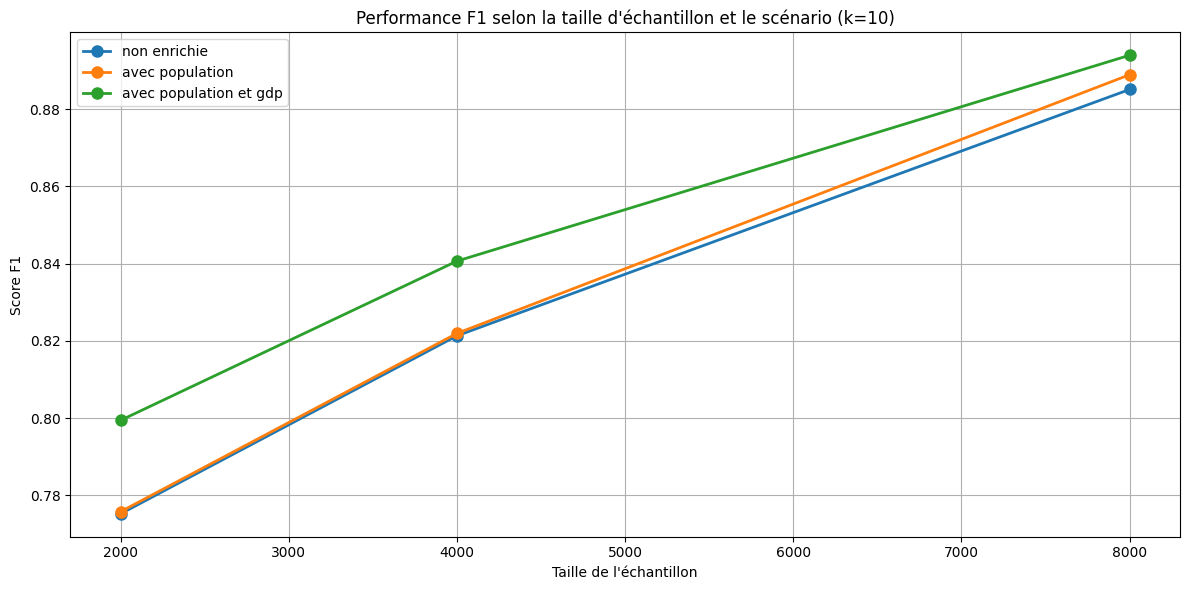

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

for scenario in ['noenrich', 'population', 'gdppop']:
    f1_scores_k10 = [results[scenario][size]['k10']['test_f1'].mean()
                    for size in sample_size]
    ax.plot(sample_size, f1_scores_k10, marker='o', linewidth=2,
            label=scenario_pretty_name[scenario], markersize=8)

ax.set_xlabel('Taille de l\'échantillon')
ax.set_ylabel('Score F1')
ax.set_title('Performance F1 selon la taille d\'échantillon et le scénario (k=10)')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

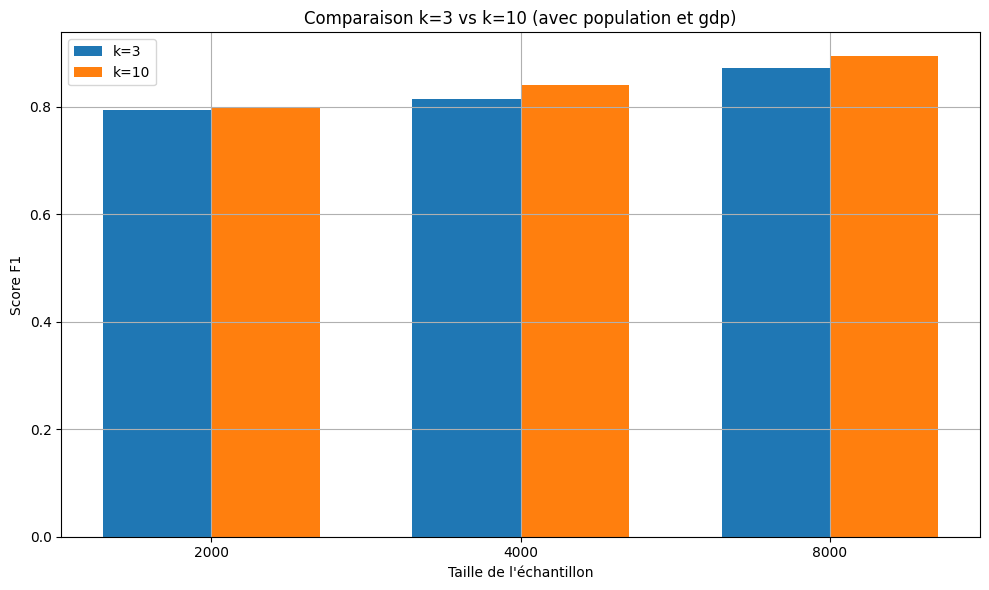

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

f1_k3 = [results['gdppop'][size]['k3']['test_f1'].mean() for size in sample_size]
f1_k10 = [results['gdppop'][size]['k10']['test_f1'].mean() for size in sample_size]

x = np.arange(len(sample_size))
width = 0.35

ax.bar(x - width/2, f1_k3, width, label='k=3')
ax.bar(x + width/2, f1_k10, width, label='k=10')

ax.set_xlabel('Taille de l\'échantillon')
ax.set_ylabel('Score F1')
ax.set_title('Comparaison k=3 vs k=10 (avec population et gdp)')
ax.set_xticks(x)
ax.set_xticklabels(sample_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

## 2.1.8 Interprétation des résultats
Le choix du modèle a été influencé par les métriques précédentes.

Tout d'abord, le premier graphique permet de voir clairement que les performances F1 du modèle s'améliorent proportionnellement à la taille de l'échantillon. On peut aussi voir que le modèle performe mieux avec les données supplémentaires de population et de GDP.

Ensuite, on peut remarquer que le modèle performe légèrement mieux avec un k-fold de 10, ce qui a poussé à choisir un k de 10.

Finalement, on peut observer que le grid search indiquait que les hyperparamètres `max_depth` et `min_samples_split` étaient optimaux respectivement à `None` et `2`.

Toutes ces métriques ont poussé au choix du modèle final pour les tests.

### Description du modèle final
- Scénario : **Population et GDP**
- Taille d'échantillon : **8000**
- K : **10**
- Max depth : **None**
- Min sample split : **2**

### Performances du modèle final
- Score F1 en validation : **0.89397** (89%)
- Score F1 sur le jeu de test : **0.72558** (73%)

---

# 2.2 Entraînement d'un classeur multi-classes
Dans cette section, je vais utiliser un processus similaire à la section 1 mais plutôt que répondre si un sujet est au-dessus de la moyenne ou non, cette section va viser à dire si le sujet est soit:
- Revenu bas
- Revenu moyen
- Revenu élevé

## 2.2.1 Fonction de remplacement de label

In [18]:
from sklearn.preprocessing import PowerTransformer

def remplacement_label_categories(labels):
    labels_reshaped = labels.values.reshape(-1, 1)
    pt = PowerTransformer(standardize=False)
    labels_transformed = pt.fit_transform(labels_reshaped).flatten()

    mean = labels_transformed.mean()
    std = labels_transformed.std()

    labels_multiclass = np.ones(len(labels_transformed), dtype=int)
    labels_multiclass[labels_transformed < (mean - std)] = 0
    labels_multiclass[labels_transformed > (mean + std)] = 2

    return labels_multiclass

## 2.2.2 Choix du meilleur classeur

Pour choisir, on va suivre le même processus que le classeur binaire. C'est-à-dire :
1. Échantillonnage
2. Entraînement par validation croisée
3. Calcul des hyperparamètres
4. Test du modèle

### 1. Échantillonnage

In [19]:
from sklearn.utils import resample

sample_size = [2000, 4000, 8000]

samples = {
    'noenrich': {},
    'population': {},
    'gdppop': {}
}

labels = {}

train_label_cat = remplacement_label_categories(train_label)
test_label_cat = remplacement_label_categories(test_label)

for size in sample_size:
    set_sample, label_sample = resample(
        train_set,
        train_label_cat,
        n_samples=size,
        random_state=RANDOM_STATE,
        stratify=train_label_cat
    )
    
    samples['noenrich'][size] = pipeline_noenrich.fit_transform(set_sample)
    samples['population'][size] = pipeline_population.fit_transform(set_sample)
    samples['gdppop'][size] = pipeline_gdppop.fit_transform(set_sample)

    labels[size] = label_sample

### 2. Validation croisée

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
import time

DTC = DecisionTreeClassifier(random_state=RANDOM_STATE)

scoring = {
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1': make_scorer(f1_score, average='weighted')
}

results = {
    'noenrich': {},
    'population': {},
    'gdppop': {}
}

for scenario in samples:
    for size in samples[scenario]:
        X_train_set = samples[scenario][size]
        y_train_label = labels[size]

        start_time = time.time()
        score_k3 = cross_validate(DTC, X_train_set, y_train_label, cv=3, scoring=scoring)
        end_time = time.time()
        k3_timing = end_time - start_time
        
        start_time = time.time()
        score_k10 = cross_validate(DTC, X_train_set, y_train_label, cv=10, scoring=scoring)
        end_time = time.time()
        k10_timing = end_time - start_time
    
        results[scenario][size] = {}
        results[scenario][size]['k3'] = score_k3
        results[scenario][size]['k3']['time'] = k3_timing
        results[scenario][size]['k10'] = score_k10
        results[scenario][size]['k10']['time'] = k10_timing

In [24]:
print_training_stats()

== Resultat scenario non enrichie ==
Name   : Precision | Recall  | F1      | Time
k3 2000: 0.73849   | 0.73950 | 0.73853 | 0.05s
k3 4000: 0.79215   | 0.78900 | 0.79018 | 0.08s
k3 8000: 0.85176   | 0.85050 | 0.85074 | 0.18s

k10 2000: 0.77139   | 0.77250 | 0.77128 | 0.19s
k10 4000: 0.81168   | 0.81025 | 0.81028 | 0.37s
k10 8000: 0.88442   | 0.88362 | 0.88374 | 0.85s
== Resultat scenario avec population ==
Name   : Precision | Recall  | F1      | Time
k3 2000: 0.74099   | 0.74300 | 0.74176 | 0.05s
k3 4000: 0.78982   | 0.78775 | 0.78852 | 0.09s
k3 8000: 0.85055   | 0.84975 | 0.84991 | 0.20s

k10 2000: 0.76554   | 0.76300 | 0.76347 | 0.20s
k10 4000: 0.81131   | 0.80900 | 0.80964 | 0.40s
k10 8000: 0.88464   | 0.88375 | 0.88392 | 0.91s
== Resultat scenario avec population et gdp ==
Name   : Precision | Recall  | F1      | Time
k3 2000: 0.77260   | 0.76950 | 0.77069 | 0.04s
k3 4000: 0.81129   | 0.81025 | 0.81053 | 0.08s
k3 8000: 0.85648   | 0.85513 | 0.85557 | 0.17s

k10 2000: 0.77351   | 0.

### 3. Calcul des hyperparamètres

In [23]:
from sklearn.model_selection import GridSearchCV
import time

best_model = {
    'noenrich': {},
    'population': {},
    'gdppop': {}
}

param_grid = {
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20, 50]
}

stats = {
    'noenrich': {},
    'population': {},
    'gdppop': {}
}
            
for scenario in samples:
    for size in samples[scenario]:
        X_train_set = samples[scenario][size]
        y_train_label = labels[size]

        start_time = time.time()
        grid_search = GridSearchCV(
            DecisionTreeClassifier(random_state=RANDOM_STATE),
            param_grid,
            cv=10,
            scoring=make_scorer(f1_score, average='weighted'),
            return_train_score=True
        )

        grid_search.fit(X_train_set, y_train_label)
        end_time = time.time()
        timing = end_time - start_time

        best_model[scenario][size] = grid_search.best_estimator_

        stats[scenario][size] = {}
        stats[scenario][size]['score'] = f"{grid_search.best_score_:.5f}"
        stats[scenario][size]['best_params'] = grid_search.best_params_
        stats[scenario][size]['time'] = timing

In [25]:
print_grid_search_stats()

Meilleur param pour non enrichie - 2000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.77128 | Time: 2.90s
Meilleur param pour non enrichie - 4000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.81028 | Time: 4.85s
Meilleur param pour non enrichie - 8000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.88374 | Time: 9.50s
Meilleur param pour avec population - 2000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.76347 | Time: 3.19s
Meilleur param pour avec population - 4000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.80964 | Time: 5.70s
Meilleur param pour avec population - 8000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.88392 | Time: 11.59s
Meilleur param pour avec population et gdp - 2000: {'max_depth': 15, 'min_samples_split': 2} | Score: 0.78145 | Time: 3.39s
Meilleur param pour avec population et gdp - 4000: {'max_depth': 20, 'min_samples_split': 2} | Score: 0.82627 | Time: 6.44s
Meilleur param pour avec population et gdp - 8

### 4. Test du modèle

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

model = best_model['gdppop'][8000]
X_test = pipeline_gdppop.transform(test_set)
y_test = test_label_cat

y_pred = model.predict(X_test)

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Test Set Results:")
print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1-Score: {f1:.5f}")

Test Set Results:
Precision: 0.72854
Recall: 0.73200
F1-Score: 0.72987


### Affichage de métrique

In [30]:
print_grid_search_stats()

Meilleur param pour non enrichie - 2000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.77128 | Time: 2.90s
Meilleur param pour non enrichie - 4000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.81028 | Time: 4.85s
Meilleur param pour non enrichie - 8000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.88374 | Time: 9.50s
Meilleur param pour avec population - 2000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.76347 | Time: 3.19s
Meilleur param pour avec population - 4000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.80964 | Time: 5.70s
Meilleur param pour avec population - 8000: {'max_depth': None, 'min_samples_split': 2} | Score: 0.88392 | Time: 11.59s
Meilleur param pour avec population et gdp - 2000: {'max_depth': 15, 'min_samples_split': 2} | Score: 0.78145 | Time: 3.39s
Meilleur param pour avec population et gdp - 4000: {'max_depth': 20, 'min_samples_split': 2} | Score: 0.82627 | Time: 6.44s
Meilleur param pour avec population et gdp - 8

In [31]:
print_training_stats()

== Resultat scenario non enrichie ==
Name   : Precision | Recall  | F1      | Time
k3 2000: 0.73849   | 0.73950 | 0.73853 | 0.05s
k3 4000: 0.79215   | 0.78900 | 0.79018 | 0.08s
k3 8000: 0.85176   | 0.85050 | 0.85074 | 0.18s

k10 2000: 0.77139   | 0.77250 | 0.77128 | 0.19s
k10 4000: 0.81168   | 0.81025 | 0.81028 | 0.37s
k10 8000: 0.88442   | 0.88362 | 0.88374 | 0.85s
== Resultat scenario avec population ==
Name   : Precision | Recall  | F1      | Time
k3 2000: 0.74099   | 0.74300 | 0.74176 | 0.05s
k3 4000: 0.78982   | 0.78775 | 0.78852 | 0.09s
k3 8000: 0.85055   | 0.84975 | 0.84991 | 0.20s

k10 2000: 0.76554   | 0.76300 | 0.76347 | 0.20s
k10 4000: 0.81131   | 0.80900 | 0.80964 | 0.40s
k10 8000: 0.88464   | 0.88375 | 0.88392 | 0.91s
== Resultat scenario avec population et gdp ==
Name   : Precision | Recall  | F1      | Time
k3 2000: 0.77260   | 0.76950 | 0.77069 | 0.04s
k3 4000: 0.81129   | 0.81025 | 0.81053 | 0.08s
k3 8000: 0.85648   | 0.85513 | 0.85557 | 0.17s

k10 2000: 0.77351   | 0.

## Meilleur classeur
Avec les métriques, on peut observer que le meilleur modèle utilise des paramètres similaires au modèle binaire.
Le modèle utilise un K de 10. Il utilise aussi un sample size de 8000. Les hyperparamètres sont les mêmes avec `max_depth` à `None` et `min_samples_split` à 2.

### Description du modèle final multi
- Scénario : **Population et GDP**
- Taille d'échantillon : **8000**
- K : **10**
- Max depth : **None**
- Min sample split : **2**

### Performances du modèle final multi
- Score F1 en validation : **0.88451** (88%)
- Score F1 sur le jeu de test : **0.72987** (73%)